# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 9 - Time Series Forecast - Part 2


# ARIMA

ARIMA, which stands for Autoregressive Integrated Moving Average, is a versatile model for analyzing and forecasting time series data. It decomposes data into three main components:

1 - Autoregression (AR): This component captures the influence of past values ​​of a series on its future values. In simpler terms, AR considers how past observations (lags) affect the current value. It is denoted as AR(p), where 'p' represents the number of lagged observations included in the model.

2 - Differentiation (I): Stationarity is a crucial assumption for many time series analyses. Differentiation involves subtracting a previous value from the current value, usually required to achieve stationarity. The degree of differencing required is denoted by I(d).

3 - Moving Average (MA): This component considers the effect of past forecast errors (residuals) on the current forecast. It considers the average of past errors (lags) to improve forecast accuracy. MA is denoted by MA(q), where 'q' represents the number of lagged errors incorporated in the model.

For example, imagine forecasting monthly sales figures for a clothing store. ARIMA can model and forecast future sales based on past sales data. It considers trends in sales, the influence of past sales on current sales (AR), and the impact of past forecast errors (MA) to refine future forecasts.

## ARIMA model types

- ARIMA: Non-Seasonal Autoregressive Integrated Moving Averages
- SARIMA: Seasonal ARIMA
- SARIMAX: Seasonal ARIMA with Exogenous Variables

If a time series has seasonal patterns, then we need to add seasonal terms and it becomes SARIMA, short for Seasonal ARIMA.

## The meaning of p, d and q in the ARIMA model

### The meaning of p

p is the order of the Auto Regressive (AR) term. It refers to the number of lags of Y to be used as predictors.

### The meaning of d

The term Autoregressive in ARIMA means that it is a linear regression model that uses its own lags as predictors. Linear regression models, as we know, work best when the predictors are uncorrelated and independent of each other. So, we need to make the time series stationary.
The most common approach to make the series stationary is to differencing it. That is, subtracting the previous value from the current value. Sometimes, depending on the complexity of the series, more than one differencing may be required.
The value of d, therefore, is the minimum number of differencing required to make the series stationary. If the time series is already stationary, then d = 0.

### The meaning of q

q is the order of the Moving Average (MA) term. It refers to the number of lagged forecast errors that should enter the ARIMA Model.

Let's then connect to Drive to access our database for our example:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

We will use Solar Flux data:

Download link: https://drive.google.com/file/d/1UGyuZyEVGc_Csc7TnNwtfp1KJRXr2_lw/view?usp=sharing

In [ ]:
path = '/content/drive/MyDrive/Datasets_TS/Ch05_Sunspots_database.csv'

In [ ]:
df_sunspots = pd.read_csv(path, index_col=0)

In [ ]:
df_sunspots

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3247,2019-08-31,0.5
3248,2019-09-30,1.1
3249,2019-10-31,0.4
3250,2019-11-30,0.5


We convert the Date column to our index:

In [ ]:
df_sunspots.index = pd.to_datetime(df_sunspots.Date)

In [ ]:
df_sunspots

,Date,Monthly Mean Total Sunspot Number
Date,,
1749-01-31,1749-01-31,96.7
1749-02-28,1749-02-28,104.3
1749-03-31,1749-03-31,116.7
1749-04-30,1749-04-30,92.8
1749-05-31,1749-05-31,141.7
...,...,...
2019-08-31,2019-08-31,0.5
2019-09-30,2019-09-30,1.1
2019-10-31,2019-10-31,0.4


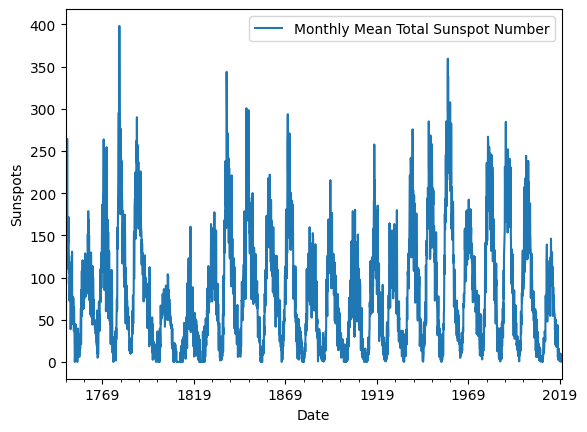

In [ ]:
ax = df_sunspots.plot()
ax.set_ylabel('Sunspots')
plt.show()

Let's select the data between 2015 and 2020:

In [ ]:
df_sunspots_range = df_sunspots[(df_sunspots.index >= '2015-01-01') & (df_sunspots.index <= '2020-12-31')]
df_sunspots_range

,Date,Monthly Mean Total Sunspot Number
Date,,
2015-01-31,2015-01-31,93.0
2015-02-28,2015-02-28,66.7
2015-03-31,2015-03-31,54.5
2015-04-30,2015-04-30,75.3
2015-05-31,2015-05-31,88.8
2015-06-30,2015-06-30,66.5
2015-07-31,2015-07-31,65.8
2015-08-31,2015-08-31,64.4
2015-09-30,2015-09-30,78.6


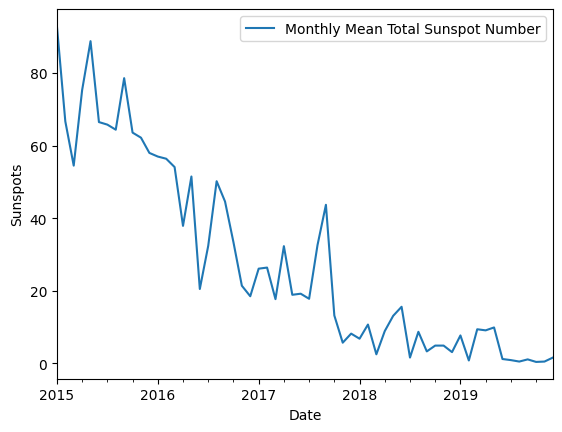

In [ ]:
ax = df_sunspots_range.plot()
ax.set_ylabel('Sunspots')
plt.show()

## ARIMA model

An ARIMA model is one in which the time series has been differenced at least once to make it stationary and we combine the AR and MA terms. So the equation of an ARIMA model becomes:

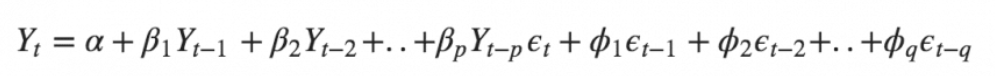

Predicted Yt = constant + linear combination of Y lags (up to p lags) + linear combination of lagged forecast errors (up to q lags)

## How to find the order of differentiation (d) in ARIMA model

As stated earlier, the purpose of differencing is to make the time series stationary. But we must be careful not to over-differentiate the series.

An over-differenced series may still be stationary, which in turn will affect the model parameters.

So, we must determine the correct order of differencing. The correct order of differencing is the minimum differencing required to obtain a quasi-stationary series that wanders around a defined mean and the ACF plot goes to zero very quickly.

If the autocorrelations are positive for many numbers of lags (10 or more), then the series needs more differencing. On the other hand, if the autocorrelation at lag 1 itself is very negative, then the series is probably over-differenced.

If we cannot really decide between two orders of differencing, then we go with the order that gives the smallest standard deviation in the differenced series.

Now, we will explain these concepts with the help of an example as follows:

- First, I will check if the series is stationary using the Augmented Dickey Fuller Test (ADF Test) from the statsmodels package. The reason is that we need to differentiate only if the series is non-stationary. Otherwise, no differentiation is required, i.e., d=0.

- The null hypothesis (Ho) of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05), we reject the null hypothesis and infer that the time series is indeed stationary.

- So, in our case, if P Value > 0.05, we proceed with finding the order of differentiation.

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(df_sunspots_range['Monthly Mean Total Sunspot Number'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -2.144182
p-value: 0.227124


Let's apply the difference:

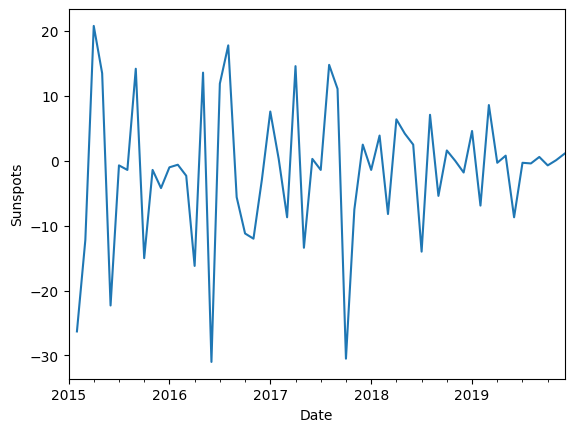

In [ ]:
ax = df_sunspots_range['Monthly Mean Total Sunspot Number'].diff().plot()
ax.set_ylabel('Sunspots')
plt.show()


## How to find the order of the AR(p) term

The next step is to identify whether the model needs any AR terms. We will find out the required number of AR terms by inspecting the Partial Autocorrelation (PACF) plot.

Partial autocorrelation can be thought of as the correlation between the series and its lag, after excluding the contributions from the intermediate lags. So, the PACF sort of conveys the pure correlation between a lag and the series. This way, we will know whether this lag is required in the AR term or not.

Now, we need to find the number of AR terms. Any autocorrelation in a stationary series can be rectified by adding enough AR terms. So, initially we take the order of the AR term to be equal to so many lags that cross the significance threshold in the PACF plot.

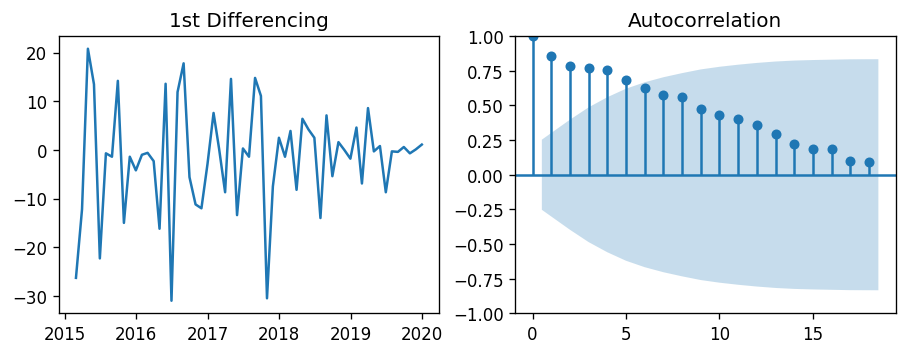

In [ ]:
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2)
axes[0].plot(df_sunspots_range['Monthly Mean Total Sunspot Number'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,5))
plot_acf(df_sunspots_range['Monthly Mean Total Sunspot Number'].dropna(), ax=axes[1])

plt.show()

## How to find the order of the term MA(q)

Just as we looked at the PACF plot for the number of AR terms, let's look at the ACF plot for the number of MA terms. One MA term is technically the lagged forecast error.

The ACF tells us how many MA terms are needed to remove any autocorrelation in the stationary series.

Let's look at the autocorrelation plot for the differenced series.

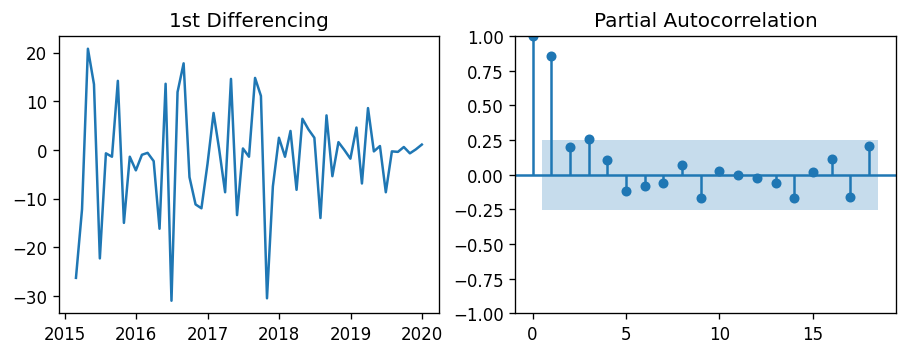

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2)
axes[0].plot(df_sunspots_range['Monthly Mean Total Sunspot Number'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_pacf(df_sunspots_range['Monthly Mean Total Sunspot Number'].dropna(), ax=axes[1])

plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 1,1,2 ARIMA Model
model = ARIMA(df_sunspots_range['Monthly Mean Total Sunspot Number'], order=(22,1,5))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                       SARIMAX Results                                       
Dep. Variable:     Monthly Mean Total Sunspot Number   No. Observations:                   60
Model:                               ARIMA(22, 1, 5)   Log Likelihood                -196.416
Date:                               Fri, 23 May 2025   AIC                            448.832
Time:                                       00:14:00   BIC                            507.004
Sample:                                   01-31-2015   HQIC                           471.540
                                        - 12-31-2019                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1849      2.125      0.087      0.931      -3.979       4.349
ar.L2      

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


We can plot the prediction graph:

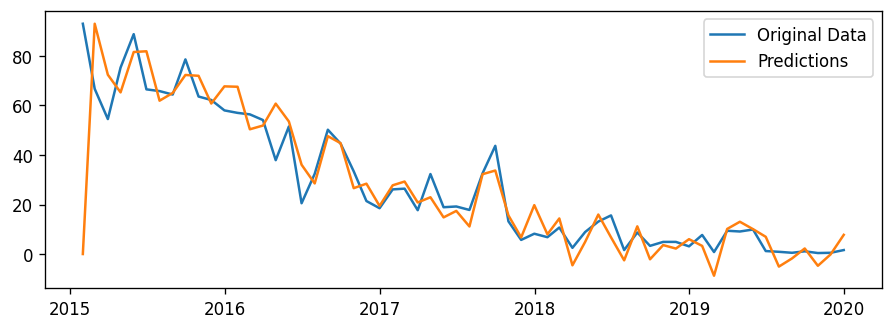

In [ ]:
predictions = model_fit.predict()

# Then, plot the original data and predictions using matplotlib
plt.plot(df_sunspots_range['Monthly Mean Total Sunspot Number'], label='Original Data')
plt.plot(predictions, label='Predictions')
plt.legend()
plt.show()

When we set dynamic=False, the lagged values ​​in the sample are used for prediction. That is, the model is trained up to the previous value to make the next prediction. This can make the adjusted prediction and the actual values ​​look artificially good.

So, it looks like we have a decent ARIMA model. But we cannot say that this is the best ARIMA model because we have not predicted the future and compared the prediction with the actual performance.

So, the real validation we need now is cross-validation

# Find the optimal ARIMA model using cross-validation

In cross-validation, we go back in time and project into the future the same number of steps as we took backwards. We then compare the prediction with the actual data.

To do this, we will create the training and testing dataset by splitting the time series into 2 contiguous parts in a reasonable proportion based on the time series frequency.

In [ ]:
from statsmodels.tsa.stattools import acf


train = df_sunspots_range['Monthly Mean Total Sunspot Number'][:45]
test = df_sunspots_range['Monthly Mean Total Sunspot Number'][45:]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum 

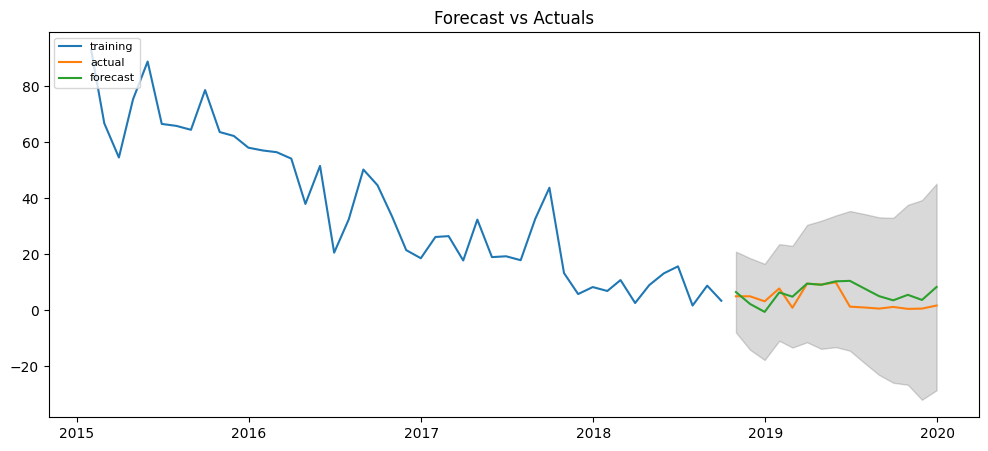

In [ ]:
model = ARIMA(train, order=(5, 1, 22))
fitted = model.fit()

# Forecast
fc = fitted.forecast(15, alpha=0.05)  # Get the forecast values
conf_int = fitted.get_forecast(15).conf_int(alpha=0.05)

lower_series = pd.Series(conf_int.iloc[:, 0], index=test.index)
upper_series = pd.Series(conf_int.iloc[:, 1], index=test.index)
fc_series = pd.Series(fc, index=test.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

# SARIMA

The simple ARIMA model has one problem. It does not support seasonality.

If the time series has a defined seasonality, then we should go for the seasonal ARIMA (in short SARIMA) model that uses seasonal differencing.

Seasonal differencing is similar to regular differencing, but instead of subtracting consecutive terms, we subtract the value of the previous season.

SARIMA (Seasonal ARIMA) builds on the strengths of ARIMA by incorporating an additional dimension: seasonality. This is particularly beneficial for data that exhibits recurring patterns at fixed intervals, such as monthly sales data with holiday spikes. Here’s how SARIMA addresses seasonality:

- Seasonal autoregression (SAR): Similar to AR, SAR considers the influence of past seasonal values ​​on the current value. It captures the impact of past seasonal patterns on future forecasts.
- Seasonal differencing (SI): Analogous to differencing, seasonal differencing focuses on removing seasonal patterns from the data to achieve stationarity.
- Seasonal moving average (SMA): This component incorporates the influence of past seasonal forecast errors on the current forecast, similar to the moving average component in ARIMA.

Now we will select data between 1940 and 2020:

In [ ]:
df_sunspots_new_range = df_sunspots[(df_sunspots.index >= '1940-01-01') & (df_sunspots.index <= '2020-12-31')]
df_sunspots_new_range

,Date,Monthly Mean Total Sunspot Number
Date,,
1940-01-31,1940-01-31,84.1
1940-02-29,1940-02-29,99.1
1940-03-31,1940-03-31,138.9
1940-04-30,1940-04-30,101.1
1940-05-31,1940-05-31,90.6
...,...,...
2019-08-31,2019-08-31,0.5
2019-09-30,2019-09-30,1.1
2019-10-31,2019-10-31,0.4


<Axes: xlabel='Date'>

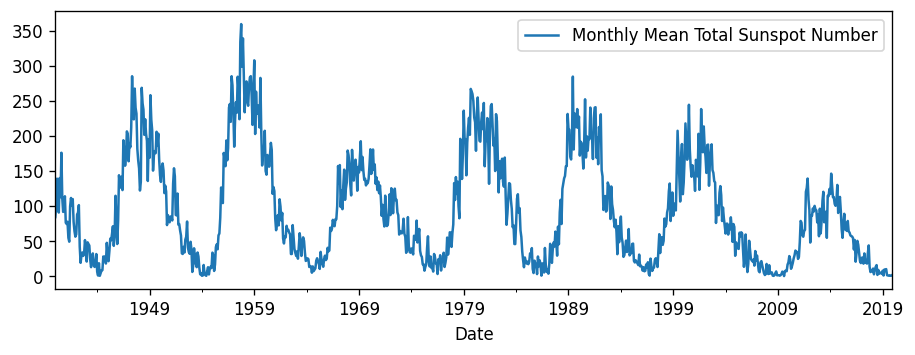

In [ ]:
df_sunspots_new_range.plot()

Let's split the data between training and testing:

In [ ]:
train = df_sunspots_new_range['Monthly Mean Total Sunspot Number'][:600]
test = df_sunspots_new_range['Monthly Mean Total Sunspot Number'][600:]

In [ ]:
import statsmodels.api as sm

In [ ]:
mod = sm.tsa.statespace.SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,120))
res = mod.fit(disp=False)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


We will apply SARIMA to 360 future points from training with past data:

In [ ]:
fcst = res.forecast(steps=360)

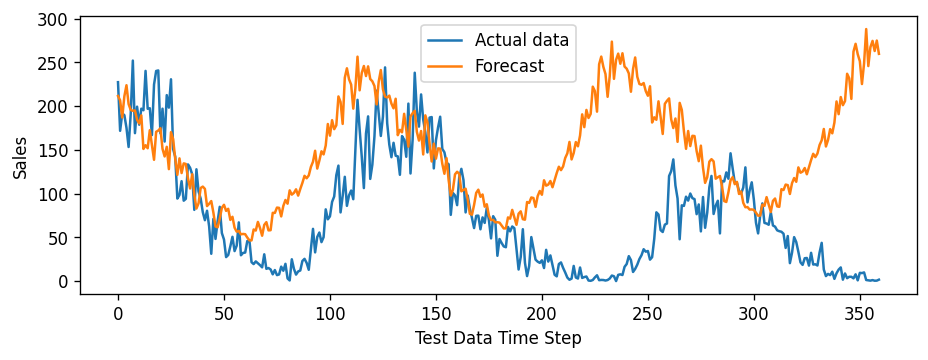

In [ ]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()

#SARIMAX

The Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors (SARIMAX) model is a powerful time series forecasting technique that extends the traditional ARIMA model to account for seasonality and external factors. It is a versatile model that can accommodate both autoregressive (AR) and moving average (MA) components, integrate differencing to make data stationary, and incorporate external variables or regressors. SARIMAX is particularly valuable when dealing with time-dependent data that exhibit recurring patterns at specific time intervals.

### SARIMAX Components

- Seasonal component (S): captures periodic patterns in the data, such as weekly, monthly, or yearly cycles.

Autoregressive component (AR): represents the relationship between the current value and previous values ​​in the time series.

- Integrated component (I): involves differencing to make the time series stationary by removing trends and seasonality.

- Moving average component (MA): considers the dependence of the current value on past error terms, used to calculate the trend.

- Exogenous regressors (X): Allows for the inclusion of external variables that may affect the time series.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

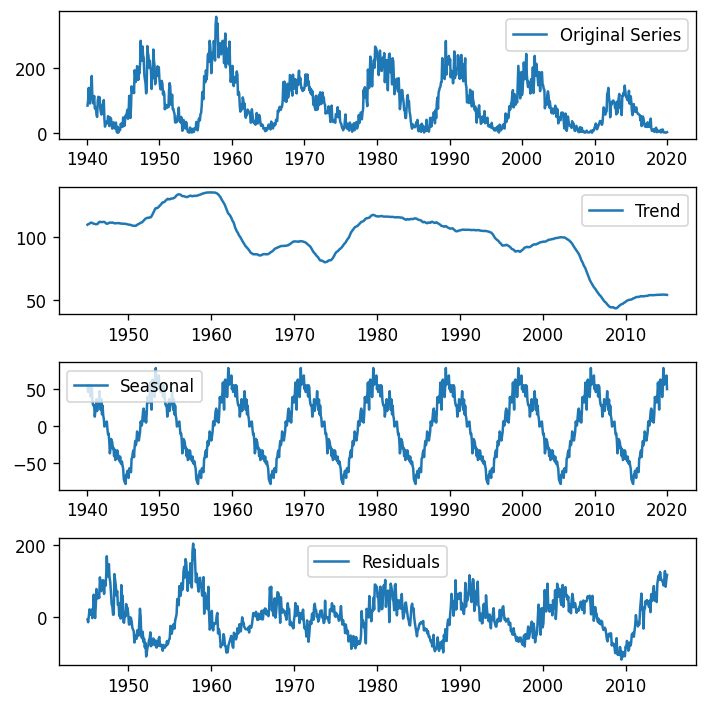

In [ ]:
result = seasonal_decompose(df_sunspots_new_range['Monthly Mean Total Sunspot Number'], model='additive', period=120)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(6,6))

plt.subplot(4, 1, 1)
plt.plot(df_sunspots_new_range['Monthly Mean Total Sunspot Number'], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

We will select seasonality data to use as exogenous data:

In [ ]:
df_sunspots_new_range['seasonal'] = seasonal

<ipython-input-37-9ff43324187a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sunspots_new_range['seasonal'] = seasonal


In [ ]:
df_sunspots_new_range

,Date,Monthly Mean Total Sunspot Number,month_index,trend,seasonal
Date,,,,,
1940-01-31,1940-01-31,84.1,1,NaN,55.392019
1940-02-29,1940-02-29,99.1,2,NaN,46.085055
1940-03-31,1940-03-31,138.9,3,NaN,47.104043
1940-04-30,1940-04-30,101.1,4,NaN,54.851364
1940-05-31,1940-05-31,90.6,5,NaN,54.501543
...,...,...,...,...,...
2019-08-31,2019-08-31,0.5,8,NaN,64.042019
2019-09-30,2019-09-30,1.1,9,NaN,60.174578
2019-10-31,2019-10-31,0.4,10,NaN,58.003031


In [ ]:
mod = sm.tsa.statespace.SARIMAX(
    endog=df_sunspots_new_range['Monthly Mean Total Sunspot Number'][:600],
    exog=df_sunspots_new_range['seasonal'][:600],
    order=(1,1,1),
    seasonal_order=(1,1,1,120),
)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
res = mod.fit()
fcst = res.forecast(steps=360, exog = df_sunspots_new_range['seasonal'][600:])

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


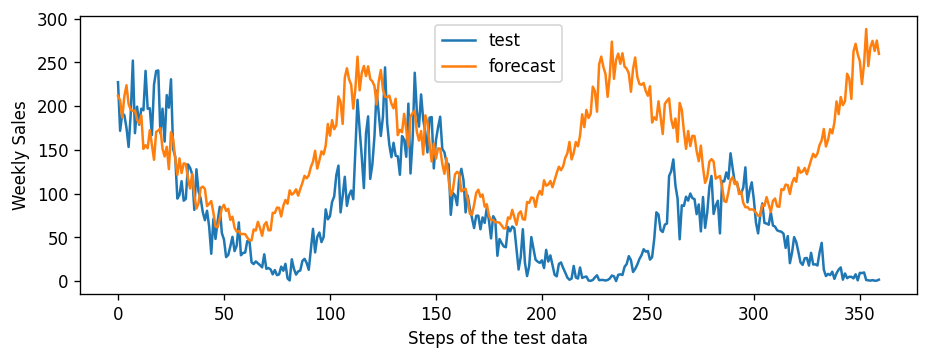

In [ ]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Weekly Sales')
plt.legend(['test', 'forecast'])
plt.show()

#VAR

Vector Autoregression (VAR) is a statistical tool used to investigate the dynamic relationships between multiple time series variables. Unlike univariate autoregressive models, which only predict a single variable based on its past values, VAR models investigate the interconnectedness of many variables. They accomplish this by modeling each variable as a function not only of its past values, but also of the past values ​​of other variables in the system.

Successful VAR modeling starts with a deep understanding of the data at hand. This step is crucial because the quality and characteristics of your data directly influence the accuracy and reliability of your model.

- Multivariate nature: VAR models thrive on the interdependence of multiple time series. For example, when forecasting electricity prices, consider how they might relate to weather conditions and gas prices. Each variable should potentially influence or be influenced by others.

- Stationarity requirement: A fundamental aspect of VAR modeling is stationarity. Simply put, the statistical properties of your series (such as mean and variance) should be constant over time. Non-stationary data can lead to misleading results, making it essential to test and, if necessary, transform your data to achieve stationarity.

- Data frequency and consistency: Ensure that your time series data is measured consistently over time. Whether it’s daily, monthly, or quarterly data, consistency in frequency is essential to maintaining the integrity of your VAR model.

- Time series length: The amount of data you have matters. Longer time series can provide more insights, but they also present challenges such as greater complexity and the potential for overfitting. Finding a balance is crucial.

- Data quality: Evaluate your data for missing values, outliers, or errors. Clean, high-quality data forms the backbone of any reliable econometric model.

- Historical context: Understand the historical context of your data. Economic and financial time series are often influenced by one-off events, policy changes, or business cycles. Recognizing these can help you interpret your model’s output more accurately.

- Preliminary analysis: Before jumping into VAR modeling, perform exploratory data analysis. Visualize your series, look for trends, seasonal patterns, and possible structural breaks. This step provides valuable insights and guides the subsequent modeling process.

Let's get a Sentinel 5P air quality time series from GEE:

In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

In [ ]:
italy = ee.Geometry.Polygon([[[8.290016551188252, 45.79137351065613],
          [8.290016551188252, 45.0588767633071],
          [10.168678660563252, 45.0588767633071],
          [10.168678660563252, 45.79137351065613]]])

In [ ]:
startDate = '2023-01-01'
endDate = '2023-12-31'

In [ ]:
s5p_no = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2').filterDate(startDate, endDate).filterBounds(italy).select('NO2_column_number_density')
s5p_co = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO').filterDate(startDate, endDate).filterBounds(italy).select('CO_column_number_density')

Let's extract the data and convert it into a DataFrame:

In [ ]:
def extract_time_series(image_collection, column):
  """Extracts the mean value of an image collection for each time step over a given region."""
  def reduce_region_func(image):
    reduced_image = image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=italy,
        scale=1113,
        maxPixels=1e13
    )
    return image.set(reduced_image)

  reduced_collection = image_collection.map(reduce_region_func)

  time_series_time = reduced_collection.aggregate_array('system:time_start').getInfo()
  time_series_values = reduced_collection.aggregate_array(column).getInfo()

  # Create a DataFrame
  time_series_df = pd.DataFrame({'time_start': time_series_time, 'value': time_series_values})
  time_series_df['time_start'] = pd.to_datetime(time_series_df['time_start'], unit='ms')
  time_series_df.set_index('time_start', inplace=True)
  return time_series_df

# Extract time series for each pollutant/parameter
no2_time_series = extract_time_series(s5p_no,'NO2_column_number_density' )
co_time_series = extract_time_series(s5p_co,'CO_column_number_density' )

In [ ]:
no2_time_series.index = no2_time_series.index.strftime('%Y-%m-%d')
co_time_series.index = co_time_series.index.strftime('%Y-%m-%d')

In [ ]:
no2_time_series_grouped = no2_time_series.groupby(no2_time_series.index).sum()
co_time_series_grouped = co_time_series.groupby(co_time_series.index).sum()

In [ ]:
df = pd.DataFrame(columns=['NO2', 'CO'])
df['NO2'] = no2_time_series_grouped['value']
df['CO'] = co_time_series_grouped['value']

In [ ]:
df

,NO2,CO
time_start,,
2023-01-01,0.000000,50.393508
2023-01-02,0.000000,144.266313
2023-01-03,0.000000,300.861444
2023-01-04,0.611969,310.111334
2023-01-05,2.356767,165.617333
...,...,...
2023-12-26,0.148370,91.730764
2023-12-27,0.389392,246.201516
2023-12-28,0.013645,108.644051


In [ ]:
df.dropna(axis=0, inplace=True)

Now let's visualize the graphs:

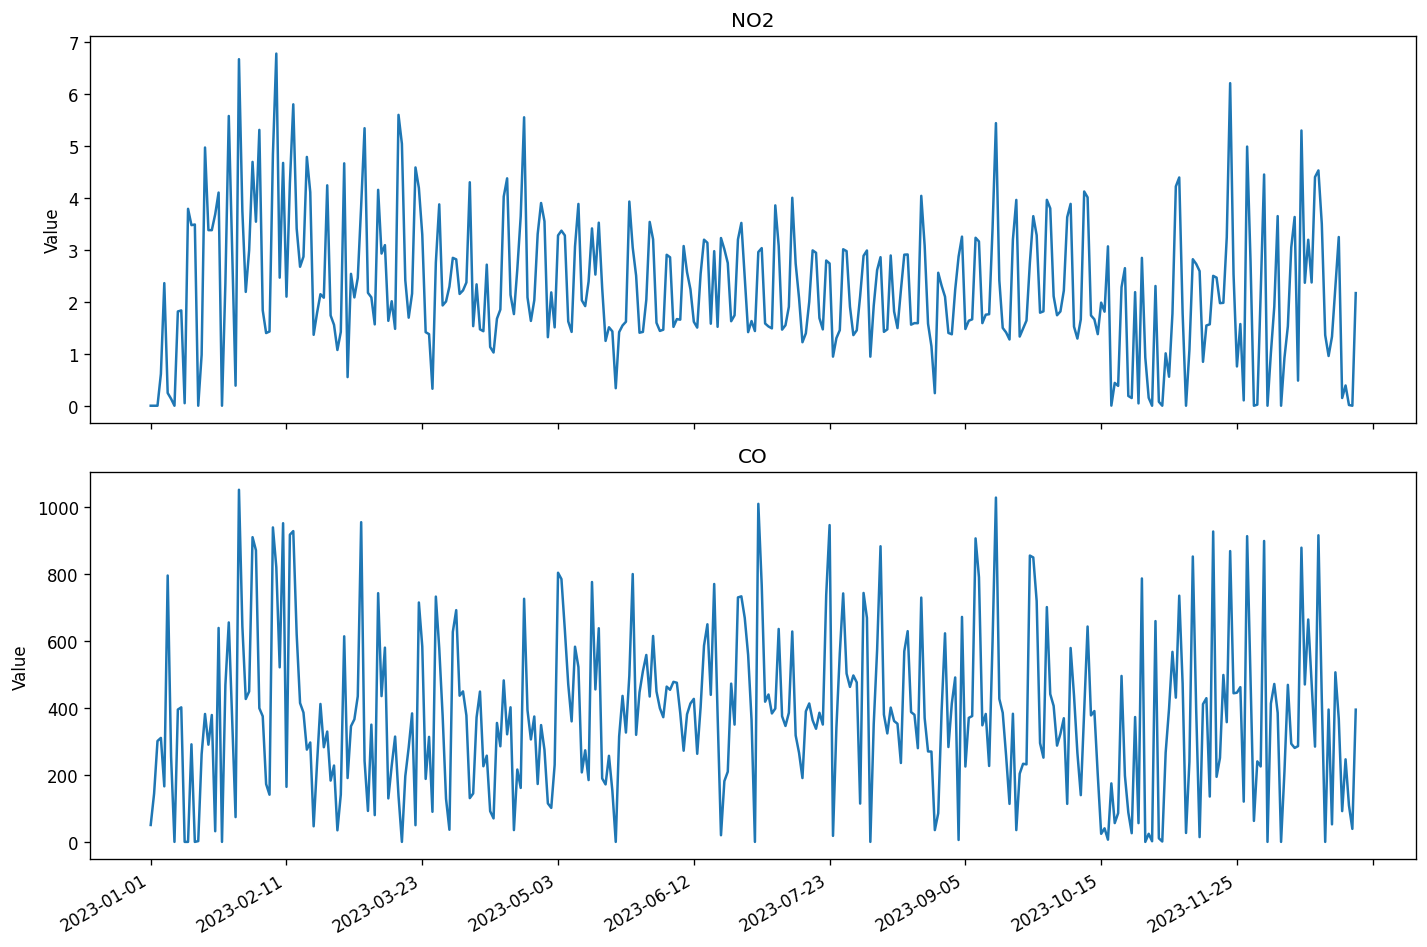

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

for i, column in enumerate(df.columns):
  axes[i].plot(df.index, df[column])
  axes[i].set_title(column)
  axes[i].set_ylabel('Value')
  axes[i].xaxis.set_major_locator(plt.MaxNLocator(10))
  fig.autofmt_xdate()

plt.tight_layout()
plt.show()

Let's also check the stationarity of the time series:

In [ ]:
from statsmodels.tsa.stattools import adfuller
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

In [ ]:
for col in df.columns:
  print('Stationarity test for', col)
  check_stationarity(df[col])

Stationarity test for NO2
ADF Statistic: -4.759372543634873
p-value: 6.500158522941053e-05
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571
Stationarity test for CO
ADF Statistic: -15.824006766090312
p-value: 1.0123421464529242e-28
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


In [ ]:
train = df[:int(0.9*(len(df)))]
valid = df[int(0.9*(len(df))):]

In Vector Autoregression (VAR) modeling, determining the correct order (number of lags) is crucial to the accuracy and efficiency of the model. The order of a VAR model indicates the number of previous time points (lags) used to predict the current value in the series. An appropriately chosen lag order captures the essential dynamics of the system without overfitting the data.

To determine the optimal lag order, we typically rely on information criteria such as the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), or the Hannan-Quinn Information Criterion (HQIC). These criteria balance model complexity (number of lags) with goodness of fit, with lower values ​​indicating a better model.

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR

model = VAR(train)

# Determining the optimal lag order
lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        11.07       11.10   6.437e+04       11.08
1        10.97      11.05*   5.838e+04       11.00
2        10.95       11.07   5.713e+04       11.00
3        10.96       11.13   5.766e+04       11.03
4        10.94       11.16   5.635e+04       11.03
5        10.88       11.15   5.313e+04       10.99
6       10.85*       11.17  5.163e+04*      10.98*
7        10.86       11.22   5.219e+04       11.01
8        10.86       11.27   5.191e+04       11.02
9        10.87       11.33   5.261e+04       11.05
10       10.86       11.37   5.204e+04       11.06
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Once we have determined the optimal lag order for our VAR model, the next step is to estimate the VAR model itself. This involves fitting the model to our time series data with the chosen lag order. Estimating a VAR model provides us with coefficients that describe the relationships between each pair of time series in the system. These coefficients are essential for understanding how changes in one variable affect others and for predicting future values ​​of the time series.

In [ ]:
model = VAR(train)
model_fitted = model.fit(6, ic='aic', trend='ct')

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


We apply the prediction to the size of our test dataset:

In [ ]:
forecast_steps = len(valid)  # Number of steps to forecast ahead
forecast = model_fitted.forecast(model_fitted.endog, steps=forecast_steps)

In [ ]:
forecast_df = pd.DataFrame(forecast, index=valid.index, columns=valid.columns)

We can visualize the results:

In [ ]:
forecast_df

,NO2,CO
time_start,,
2023-11-25,1.145506,317.773888
2023-11-26,1.515275,331.262650
2023-11-27,2.752172,523.603621
2023-11-28,3.332614,562.688236
2023-11-29,2.967959,476.267811
2023-11-30,1.704660,360.788448
2023-12-01,1.411222,350.505178
2023-12-02,1.973411,410.827690
2023-12-03,2.575303,475.771710


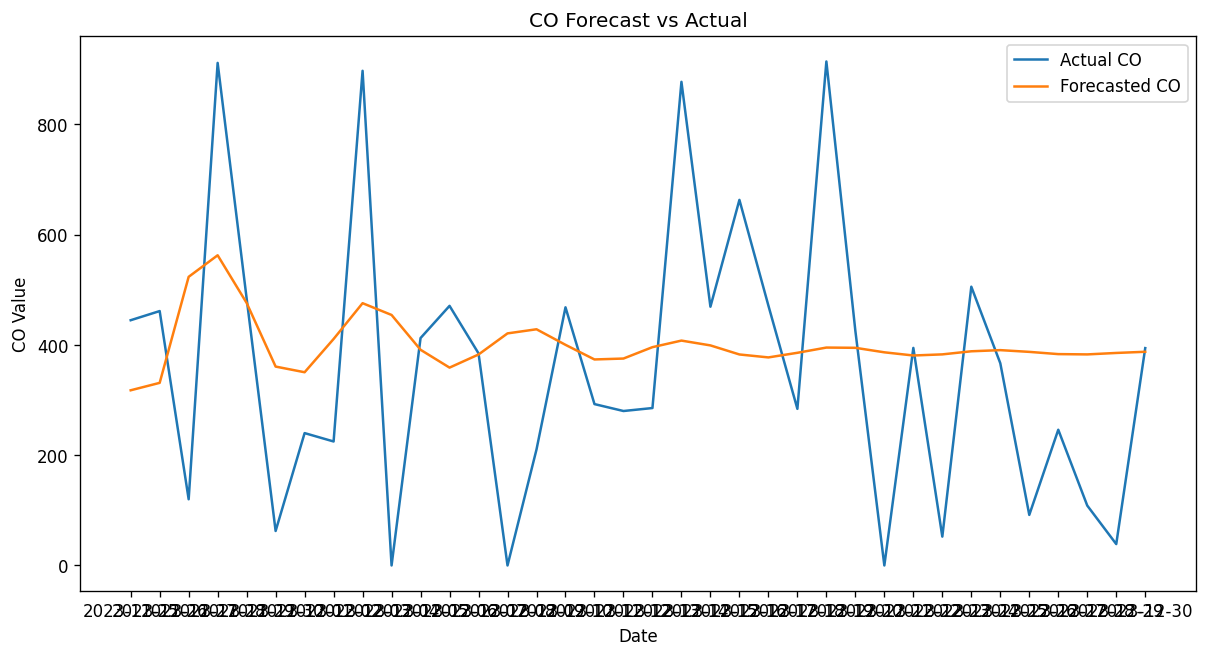

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(valid['CO'], label='Actual CO')
plt.plot(forecast_df['CO'], label='Forecasted CO')
plt.title('CO Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('CO Value')
plt.legend()
plt.show()

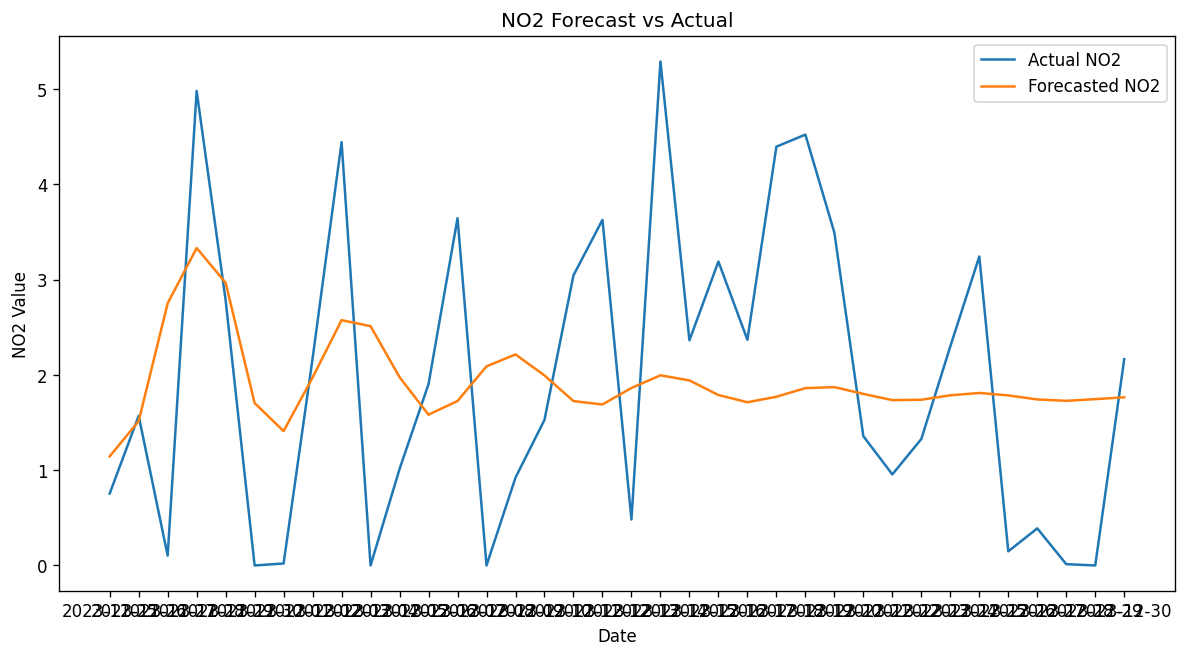

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(valid['NO2'], label='Actual NO2')
plt.plot(forecast_df['NO2'], label='Forecasted NO2')
plt.title('NO2 Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('NO2 Value')
plt.legend()
plt.show()

## Thank you! See you in the next Chapter!

References:

https://www.kaggle.com/code/prashant111/arima-model-for-time-series-forecasting

https://www.geeksforgeeks.org/python-arima-model-for-time-series-forecasting/?ref=ml_lbp

https://www.geeksforgeeks.org/arima-vs-sarima-model/?ref=ml_lbp

https://www.geeksforgeeks.org/vector-autoregression-var-for-multivariate-time-series/?ref=ml_lbp

https://medium.com/@Alidotab/mastering-forecasting-unveiling-the-power-of-var-modeling-for-dynamic-time-series-prediction-1b87a7d63b4b

https://www.kaggle.com/code/ujoshi076/multivariate-time-series-analysis-using-var-model